# Navier-Stokes PINN (PyTorch)

This is a compact PyTorch notebook for reproducing the continuous-time inverse Navier-Stokes example from the PINNs paper.

This version follows the style of the current `Schrodinger.ipynb`:
- reads `cylinder_nektar_wake.mat` by default
- trains directly with `Adam`

The governing equations are:

$$u_t + \lambda_1(uu_x + vu_y) = -p_x + \lambda_2(u_{xx} + u_{yy})$$
$$v_t + \lambda_1(uv_x + vv_y) = -p_y + \lambda_2(v_{xx} + v_{yy})$$

The network approximates

$$[\psi(x, y, t), p(x, y, t)]$$

and then defines

$$u = \psi_y, \quad v = -\psi_x$$

so that the incompressibility condition `u_x + v_y = 0` is satisfied automatically.


In [1]:
from pathlib import Path
import random
import time
from typing import List, Optional, Union

import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import torch
import torch.nn as nn


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device)
device


device(type='cuda')

In [3]:
dtype = torch.float32
seed = 1234

n_train = 5000
layers = (3, 20, 20, 20, 20, 20, 20, 20, 20, 2)

lambda1_init = 0.0
lambda2_init = 0.0

adam_steps = 5000
adam_lr = 1e-3
weight_decay = 0.0
loss_weight = 0.5
noise_type = "gaussian"
noise_level = 0.05
print_every = 100

plot_t_idx = 100
eval_subset_size = 100000

torch.set_default_dtype(dtype)


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(seed)

print(
    f"n_train={n_train}, adam_steps={adam_steps}, eval_subset_size={eval_subset_size}, "
    f"loss_weight={loss_weight}, pde_weight={1.0 - loss_weight}, "
    f"noise_type={noise_type}, noise_level={noise_level}"
)


n_train=5000, adam_steps=5000, eval_subset_size=100000, loss_weight=0.5, pde_weight=0.5, noise_type=gaussian, noise_level=0.05


## Paper Settings

This notebook keeps the main paper-style settings:

- randomly samples `5000` space-time points for training
- uses the network width `[3, 20, 20, 20, 20, 20, 20, 20, 20, 2]`
- applies data supervision only to `u, v`
- identifies `lambda_1, lambda_2` simultaneously

For convenience, the notebook evaluates `rel L2` on a fixed random subset and also visualizes one full time slice separately.


This notebook uses `../data/cylinder_nektar_wake.mat` by default.


In [4]:
DATA_DIR = Path("../data").resolve()
MAT_PATH = DATA_DIR / "cylinder_nektar_wake.mat"


def load_reference_solution(mat_path: Path) -> dict[str, np.ndarray]:
    raw = scipy.io.loadmat(mat_path)
    return {
        "x": raw["X_star"][:, 0:1].astype("float32"),
        "y": raw["X_star"][:, 1:2].astype("float32"),
        "t": raw["t"].astype("float32"),
        "u": raw["U_star"][:, 0, :].astype("float32"),
        "v": raw["U_star"][:, 1, :].astype("float32"),
        "p": raw["p_star"].astype("float32"),
    }


reference = load_reference_solution(MAT_PATH)
reference.keys()


dict_keys(['x', 'y', 't', 'u', 'v', 'p'])

## Reference Data Visualization


In [5]:
print("cylinder_nektar_wake.mat dimensions:")
print(f"x: {reference['x'].shape}")
print(f"y: {reference['y'].shape}")
print(f"t: {reference['t'].shape}")
print(f"u: {reference['u'].shape}")
print(f"v: {reference['v'].shape}")
print(f"p: {reference['p'].shape}")


cylinder_nektar_wake.mat dimensions:
x: (5000, 1)
y: (5000, 1)
t: (200, 1)
u: (5000, 200)
v: (5000, 200)
p: (5000, 200)


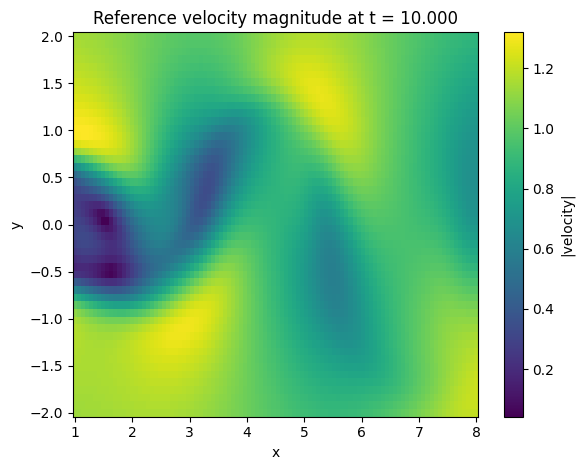

In [6]:
nx = np.unique(reference["x"][:, 0]).size
ny = np.unique(reference["y"][:, 0]).size

x_grid = reference["x"].reshape(ny, nx)
y_grid = reference["y"].reshape(ny, nx)
speed_ref = np.sqrt(reference["u"][:, plot_t_idx] ** 2 + reference["v"][:, plot_t_idx] ** 2)
speed_grid = speed_ref.reshape(ny, nx)

plt.figure(figsize=(6, 4.8))
mesh = plt.pcolormesh(x_grid, y_grid, speed_grid, shading="auto", cmap="viridis")
plt.colorbar(mesh, label="|velocity|")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Reference velocity magnitude at t = {float(reference['t'][plot_t_idx, 0]):.3f}")
plt.tight_layout()
plt.show()


## Training Data Preparation

Here the full space-time point cloud is flattened first, and then `5000` points are sampled randomly for training.


In [7]:
def flatten_reference(reference: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    n_space = reference["x"].shape[0]
    n_time = reference["t"].shape[0]

    x = np.tile(reference["x"], (1, n_time)).reshape(-1, 1)
    y = np.tile(reference["y"], (1, n_time)).reshape(-1, 1)
    t = np.tile(reference["t"].T, (n_space, 1)).reshape(-1, 1)

    u = reference["u"].reshape(-1, 1)
    v = reference["v"].reshape(-1, 1)
    p = reference["p"].reshape(-1, 1)

    return {"x": x, "y": y, "t": t, "u": u, "v": v, "p": p}


flat_reference = flatten_reference(reference)
{key: value.shape for key, value in flat_reference.items()}


{'x': (1000000, 1),
 'y': (1000000, 1),
 't': (1000000, 1),
 'u': (1000000, 1),
 'v': (1000000, 1),
 'p': (1000000, 1)}

In [10]:
def sample_training_points(*, device: torch.device) -> dict[str, torch.Tensor]:
    total = flat_reference["x"].shape[0]
    idx = np.random.choice(total, n_train, replace=False)

    x = torch.tensor(flat_reference["x"][idx], dtype=torch.get_default_dtype(), device=device)
    y = torch.tensor(flat_reference["y"][idx], dtype=torch.get_default_dtype(), device=device)
    t = torch.tensor(flat_reference["t"][idx], dtype=torch.get_default_dtype(), device=device)
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)

    u = torch.tensor(flat_reference["u"][idx], dtype=torch.get_default_dtype(), device=device)
    v = torch.tensor(flat_reference["v"][idx], dtype=torch.get_default_dtype(), device=device)

    if noise_type == "gaussian" and noise_level > 0.0:
        # Original PINNs-style noisy observations:
        # noisy_data = clean_data + noise_level * std(clean_data) * randn(...)
        u = u + noise_level * torch.std(u, unbiased=False) * torch.randn_like(u)
        v = v + noise_level * torch.std(v, unbiased=False) * torch.randn_like(v)

    return {
        "x": x,
        "y": y,
        "t": t,
        "u": u,
        "v": v,
    }


train_points = sample_training_points(device=device)
{key: tuple(value.shape) for key, value in train_points.items()}


{'x': (5000, 1),
 'y': (5000, 1),
 't': (5000, 1),
 'u': (5000, 1),
 'v': (5000, 1)}

## Neural Network

Here `lambda_1` and `lambda_2` are treated as trainable parts of the model as well.


In [11]:
class NavierStokesPINN(nn.Module):
    def __init__(
        self,
        layers: tuple[int, ...],
        lb: tuple[float, float, float],
        ub: tuple[float, float, float],
        lambda1_init: float,
        lambda2_init: float,
    ):
        super().__init__()
        blocks = []
        for in_features, out_features in zip(layers[:-2], layers[1:-1]):
            blocks.append(nn.Linear(in_features, out_features))
            blocks.append(nn.Tanh())
        blocks.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*blocks)

        self.lambda1 = nn.Parameter(torch.tensor(lambda1_init, dtype=torch.get_default_dtype()))
        self.lambda2 = nn.Parameter(torch.tensor(lambda2_init, dtype=torch.get_default_dtype()))

        self.register_buffer("lb", torch.tensor(lb, dtype=torch.get_default_dtype()))
        self.register_buffer("ub", torch.tensor(ub, dtype=torch.get_default_dtype()))
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.xavier_normal_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        inputs = torch.cat([x, y, t], dim=1)
        inputs = 2.0 * (inputs - self.lb) / (self.ub - self.lb) - 1.0
        outputs = self.net(inputs)
        psi = outputs[:, :1]
        p = outputs[:, 1:2]
        return psi, p


## PDE Residual and Total Loss

Note: pressure is only identifiable up to an additive constant, so the evaluation stage first aligns its mean; training still learns it directly through the PDE residual.


In [12]:
def gradient(
    dy: torch.Tensor,
    dx: Union[List[torch.Tensor], torch.Tensor],
    grad_outputs: Optional[List[Optional[torch.Tensor]]] = None,
    create_graph: bool = True,
) -> List[torch.Tensor]:
    if grad_outputs is None:
        grad_outputs = [torch.ones_like(dy)]

    if isinstance(dx, torch.Tensor):
        dx = [dx]

    grads = torch.autograd.grad(
        [dy],
        dx,
        grad_outputs=grad_outputs,
        create_graph=create_graph,
        retain_graph=True,
        allow_unused=False,
    )
    return [grad if grad is not None else torch.zeros_like(dx[i]) for i, grad in enumerate(grads)]


def navier_stokes_outputs(
    model: NavierStokesPINN,
    x: torch.Tensor,
    y: torch.Tensor,
    t: torch.Tensor,
) -> dict[str, torch.Tensor]:
    psi, p = model(x, y, t)

    u = gradient(psi, y)[0]
    v = -gradient(psi, x)[0]

    u_x, u_y, u_t = gradient(u, [x, y, t])
    u_xx = gradient(u_x, x)[0]
    u_yy = gradient(u_y, y)[0]

    v_x, v_y, v_t = gradient(v, [x, y, t])
    v_xx = gradient(v_x, x)[0]
    v_yy = gradient(v_y, y)[0]

    p_x, p_y = gradient(p, [x, y])

    f_u = u_t + model.lambda1 * (u * u_x + v * u_y) + p_x - model.lambda2 * (u_xx + u_yy)
    f_v = v_t + model.lambda1 * (u * v_x + v * v_y) + p_y - model.lambda2 * (v_xx + v_yy)

    return {
        "psi": psi,
        "p": p,
        "u": u,
        "v": v,
        "f_u": f_u,
        "f_v": f_v,
    }


In [13]:
def sse(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return torch.sum((pred - target).square())


def pinn_loss_tensors(
    model: NavierStokesPINN,
    points: dict[str, torch.Tensor],
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    outputs = navier_stokes_outputs(model, points["x"], points["y"], points["t"])

    zero_u = torch.zeros_like(outputs["f_u"])
    zero_v = torch.zeros_like(outputs["f_v"])

    loss_data = sse(outputs["u"], points["u"]) + sse(outputs["v"], points["v"])
    loss_pde = sse(outputs["f_u"], zero_u) + sse(outputs["f_v"], zero_v)
    loss = loss_weight * loss_data + (1.0 - loss_weight) * loss_pde
    return loss, loss_data, loss_pde


def pinn_loss(
    model: NavierStokesPINN,
    points: dict[str, torch.Tensor],
) -> tuple[torch.Tensor, dict[str, float]]:
    loss, loss_data, loss_pde = pinn_loss_tensors(model, points)

    stats = {
        "loss": float(loss.detach().cpu()),
        "loss_data": float(loss_data.detach().cpu()),
        "loss_pde": float(loss_pde.detach().cpu()),
        "loss_weight": float(loss_weight),
        "pde_weight": float(1.0 - loss_weight),
        "lambda1": float(model.lambda1.detach().cpu()),
        "lambda2": float(model.lambda2.detach().cpu()),
    }
    return loss, stats


## Adam Training


In [14]:
def train_adam(
    model: NavierStokesPINN,
    points: dict[str, torch.Tensor],
) -> list[dict[str, float]]:
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=adam_lr,
        weight_decay=weight_decay,
    )

    history = []
    start = time.time()

    for step in range(1, adam_steps + 1):
        optimizer.zero_grad(set_to_none=True)
        loss, stats = pinn_loss(model, points)
        loss.backward()
        optimizer.step()

        stats["step"] = step
        stats["lr"] = optimizer.param_groups[0]["lr"]
        history.append(stats)

        if step % print_every == 0 or step == 1:
            elapsed = time.time() - start
            print(
                f"Adam step {step:6d} | "
                f"loss={stats['loss']:.3e} | "
                f"data={stats['loss_data']:.3e} | "
                f"pde={stats['loss_pde']:.3e} | "
                f"lambda1={stats['lambda1']:.5f} | "
                f"lambda2={stats['lambda2']:.5f} | "
                f"elapsed={elapsed:.1f}s"
            )

    return history


In [15]:
lb = (
    float(reference["x"].min()),
    float(reference["y"].min()),
    float(reference["t"].min()),
)
ub = (
    float(reference["x"].max()),
    float(reference["y"].max()),
    float(reference["t"].max()),
)

model = NavierStokesPINN(
    layers=layers,
    lb=lb,
    ub=ub,
    lambda1_init=lambda1_init,
    lambda2_init=lambda2_init,
).to(device)

train_points = sample_training_points(device=device)
adam_history = train_adam(model, train_points)


AdamW step      1 | loss=8.912e-01 | data=8.809e-01 | pde=1.028e-02 | lambda1=0.00000 | lambda2=0.00000 | elapsed=0.5s
AdamW step    100 | loss=1.139e-01 | data=1.138e-01 | pde=1.194e-04 | lambda1=-0.05946 | lambda2=-0.00096 | elapsed=10.5s
AdamW step    200 | loss=9.690e-02 | data=9.680e-02 | pde=1.012e-04 | lambda1=-0.03900 | lambda2=0.00007 | elapsed=20.0s
AdamW step    300 | loss=9.528e-02 | data=9.522e-02 | pde=6.472e-05 | lambda1=-0.03089 | lambda2=-0.00015 | elapsed=30.1s
AdamW step    400 | loss=9.482e-02 | data=9.478e-02 | pde=4.434e-05 | lambda1=-0.03296 | lambda2=-0.00031 | elapsed=40.7s
AdamW step    500 | loss=9.445e-02 | data=9.441e-02 | pde=3.757e-05 | lambda1=-0.03048 | lambda2=-0.00047 | elapsed=51.4s
AdamW step    600 | loss=9.401e-02 | data=9.398e-02 | pde=3.789e-05 | lambda1=-0.01902 | lambda2=-0.00035 | elapsed=60.8s
AdamW step    700 | loss=9.476e-02 | data=9.468e-02 | pde=8.234e-05 | lambda1=0.04204 | lambda2=0.00150 | elapsed=72.2s
AdamW step    800 | loss=9.127

## Prediction and Error Evaluation

To keep the notebook easy to run, it uses two kinds of evaluation:

- computes `rel L2` on a fixed random subset
- visualizes a full time slice at `t_idx = 100`


In [16]:
def predict_chunk(
    model: NavierStokesPINN,
    x: np.ndarray,
    y: np.ndarray,
    t: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x_tensor = torch.tensor(x, dtype=torch.get_default_dtype(), device=device)
    y_tensor = torch.tensor(y, dtype=torch.get_default_dtype(), device=device)
    t_tensor = torch.tensor(t, dtype=torch.get_default_dtype(), device=device)
    x_tensor.requires_grad_(True)
    y_tensor.requires_grad_(True)
    t_tensor.requires_grad_(True)

    model.eval()
    outputs = navier_stokes_outputs(model, x_tensor, y_tensor, t_tensor)
    return (
        outputs["u"].detach().cpu().numpy(),
        outputs["v"].detach().cpu().numpy(),
        outputs["p"].detach().cpu().numpy(),
    )


def relative_l2(pred: np.ndarray, target: np.ndarray) -> float:
    return float(np.linalg.norm(pred - target) / np.linalg.norm(target))


rng = np.random.default_rng(seed)
eval_idx = rng.choice(flat_reference["x"].shape[0], size=eval_subset_size, replace=False)

u_eval, v_eval, p_eval = predict_chunk(
    model,
    flat_reference["x"][eval_idx],
    flat_reference["y"][eval_idx],
    flat_reference["t"][eval_idx],
)

p_eval_aligned = p_eval - np.mean(p_eval - flat_reference["p"][eval_idx])

metrics = {
    "rel_l2_u": relative_l2(u_eval, flat_reference["u"][eval_idx]),
    "rel_l2_v": relative_l2(v_eval, flat_reference["v"][eval_idx]),
    "rel_l2_p": relative_l2(p_eval_aligned, flat_reference["p"][eval_idx]),
    "lambda1": float(model.lambda1.detach().cpu()),
    "lambda2": float(model.lambda2.detach().cpu()),
}

metrics


{'rel_l2_u': 0.02957962453365326,
 'rel_l2_v': 0.11202739924192429,
 'rel_l2_p': 0.25123530626296997,
 'lambda1': 0.9817319512367249,
 'lambda2': 0.011949677020311356}

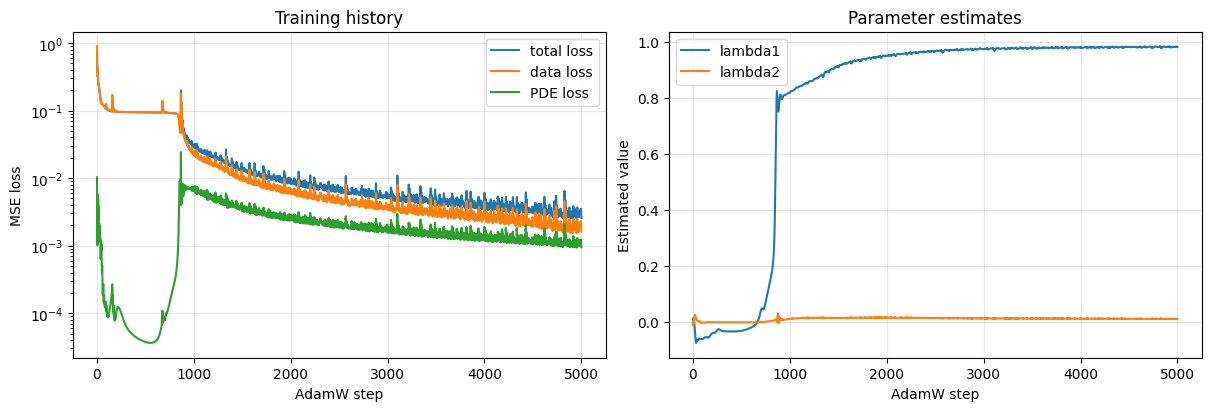

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot([row["step"] for row in adam_history], [row["loss"] for row in adam_history], label="total loss")
axes[0].plot([row["step"] for row in adam_history], [row["loss_data"] for row in adam_history], label="data loss")
axes[0].plot([row["step"] for row in adam_history], [row["loss_pde"] for row in adam_history], label="PDE loss")
axes[0].set_yscale("log")
axes[0].set_xlabel("Adam step")
axes[0].set_ylabel("SSE loss")
axes[0].set_title("Training history")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot([row["step"] for row in adam_history], [row["lambda1"] for row in adam_history], label="lambda1")
axes[1].plot([row["step"] for row in adam_history], [row["lambda2"] for row in adam_history], label="lambda2")
axes[1].set_xlabel("Adam step")
axes[1].set_ylabel("Estimated value")
axes[1].set_title("Parameter estimates")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()


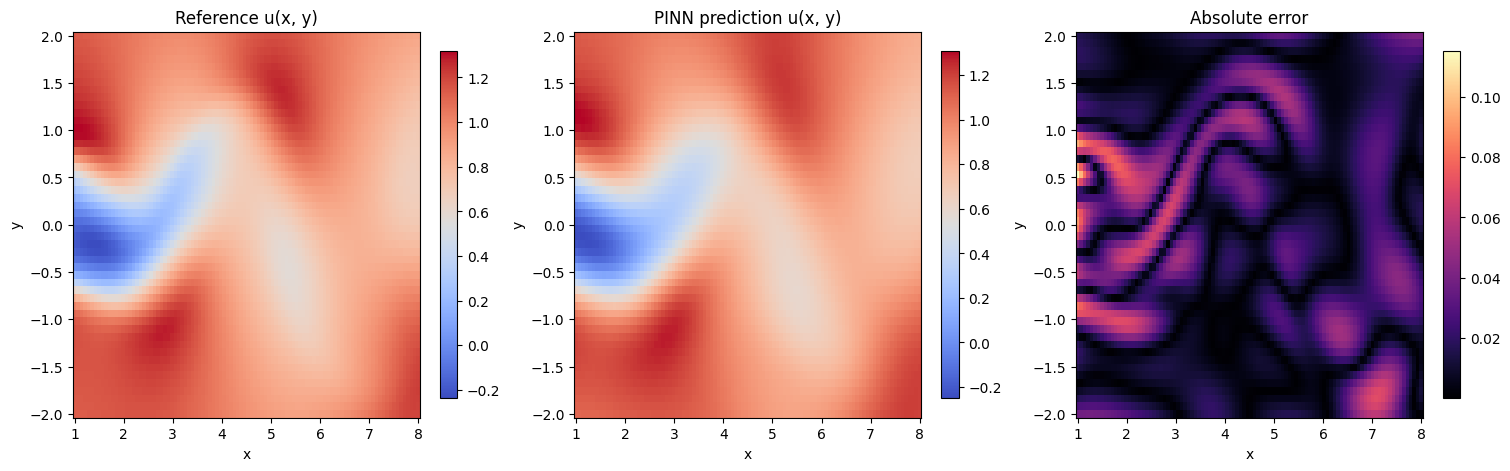

In [18]:
x_slice = reference["x"]
y_slice = reference["y"]
t_slice = np.full_like(x_slice, float(reference["t"][plot_t_idx, 0]))

u_slice_pred, _, _ = predict_chunk(model, x_slice, y_slice, t_slice)
u_slice_true = reference["u"][:, plot_t_idx : plot_t_idx + 1]

nx = np.unique(reference["x"][:, 0]).size
ny = np.unique(reference["y"][:, 0]).size
x_grid = reference["x"].reshape(ny, nx)
y_grid = reference["y"].reshape(ny, nx)
u_true_grid = u_slice_true.reshape(ny, nx)
u_pred_grid = u_slice_pred.reshape(ny, nx)
u_err_grid = np.abs(u_pred_grid - u_true_grid)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)

mesh0 = axes[0].pcolormesh(x_grid, y_grid, u_true_grid, shading="auto", cmap="coolwarm")
axes[0].set_title("Reference u(x, y)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(mesh0, ax=axes[0], shrink=0.9)

mesh1 = axes[1].pcolormesh(x_grid, y_grid, u_pred_grid, shading="auto", cmap="coolwarm")
axes[1].set_title("PINN prediction u(x, y)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(mesh1, ax=axes[1], shrink=0.9)

mesh2 = axes[2].pcolormesh(x_grid, y_grid, u_err_grid, shading="auto", cmap="magma")
axes[2].set_title("Absolute error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(mesh2, ax=axes[2], shrink=0.9)

plt.show()


## Pressure Comparison

This section also plots `reference p / prediction p / absolute error` on the same time slice. Since pressure is only defined up to a constant, the mean is aligned first.


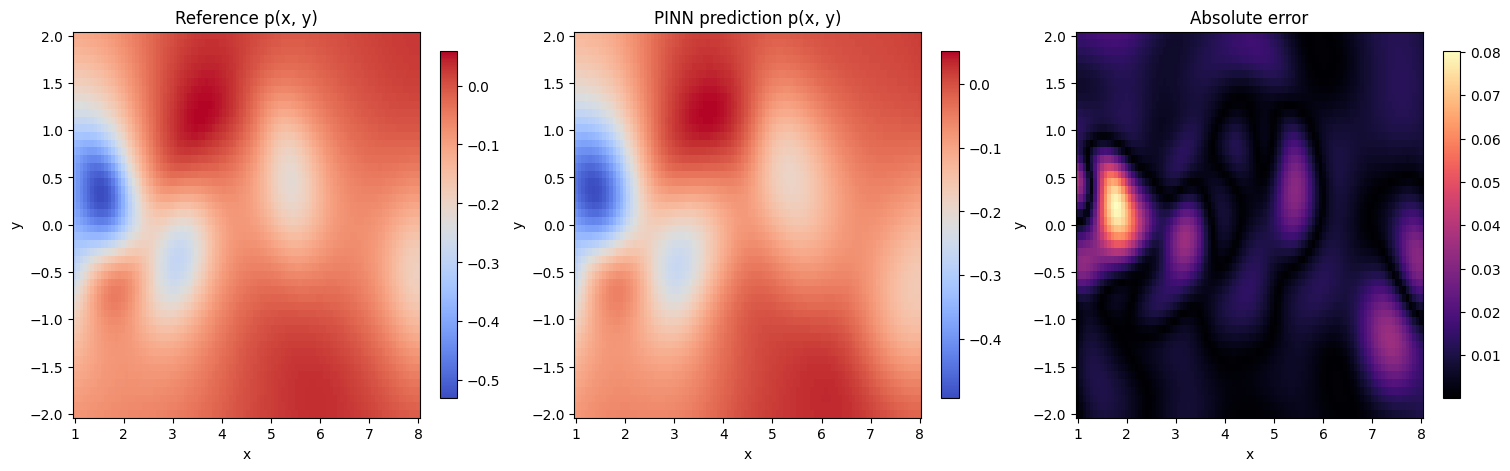

In [19]:
x_slice = reference["x"]
y_slice = reference["y"]
t_slice = np.full_like(x_slice, float(reference["t"][plot_t_idx, 0]))

_, _, p_slice_pred = predict_chunk(model, x_slice, y_slice, t_slice)
p_slice_true = reference["p"][:, plot_t_idx : plot_t_idx + 1]
p_slice_pred_aligned = p_slice_pred - np.mean(p_slice_pred - p_slice_true)

nx = np.unique(reference["x"][:, 0]).size
ny = np.unique(reference["y"][:, 0]).size
x_grid = reference["x"].reshape(ny, nx)
y_grid = reference["y"].reshape(ny, nx)
p_true_grid = p_slice_true.reshape(ny, nx)
p_pred_grid = p_slice_pred_aligned.reshape(ny, nx)
p_err_grid = np.abs(p_pred_grid - p_true_grid)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)

mesh0 = axes[0].pcolormesh(x_grid, y_grid, p_true_grid, shading="auto", cmap="coolwarm")
axes[0].set_title("Reference p(x, y)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(mesh0, ax=axes[0], shrink=0.9)

mesh1 = axes[1].pcolormesh(x_grid, y_grid, p_pred_grid, shading="auto", cmap="coolwarm")
axes[1].set_title("PINN prediction p(x, y)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(mesh1, ax=axes[1], shrink=0.9)

mesh2 = axes[2].pcolormesh(x_grid, y_grid, p_err_grid, shading="auto", cmap="magma")
axes[2].set_title("Absolute error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(mesh2, ax=axes[2], shrink=0.9)

plt.show()
